# Polyagamma GP Classifier Demo

This notebook uses the new `PolyagammaGPClassifier` API on the same toy-data recipe as `PG_GP4.ipynb`:

- random points in `[-1, 1]^2`,
- labels drawn from `Bernoulli(sigmoid(f))`,
- `f` sampled from a squared-exponential GP.

The demo is smaller than `PG_GP4.ipynb` so it runs quickly, but it exercises the new library interface end to end.


In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

ROOT = Path.cwd().resolve()
PARENT = ROOT.parent
if str(PARENT) not in sys.path:
    sys.path.append(str(PARENT))

from vanilla_gp_sampling import sample_bernoulli_gp
from pg_classifier import PolyagammaGPClassifier

torch.set_default_dtype(torch.float64)
torch.manual_seed(7)
np.random.seed(7)

plt.style.use("seaborn-v0_8-whitegrid")


## Generate The Same Style Of Toy Data As `PG_GP4.ipynb`

We keep the 2D random-input construction and the same `sample_bernoulli_gp(...)` helper, but use a smaller problem size for a compact demo notebook.


In [ ]:
n_train = 50_000
d = 2
true_length_scale = 0.7
true_variance = 1.0
grid_size = 24

X_train = torch.rand(n_train, d) * 2.0 - 1.0
grid_1d = torch.linspace(-1.1, 1.1, grid_size)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="ij")
X_grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

X_all = torch.cat([X_train, X_grid], dim=0)
y_all, f_all = sample_bernoulli_gp(
    X_all,
    length_scale=true_length_scale,
    variance=true_variance,
    noise_variance=1e-4,
    seed=11,
)

y_train = y_all[:n_train]
f_grid_true = f_all[n_train:]
p_grid_true = torch.sigmoid(f_grid_true)

X_train_np = X_train.cpu().numpy()
y_train_np = y_train.cpu().numpy().astype(int)
X_grid_np = X_grid.cpu().numpy()
grid_1d_np = grid_1d.cpu().numpy()

print(f"Training points: {n_train}")
print(f"Grid points: {X_grid_np.shape[0]}")
print(f"Positive class fraction: {y_train_np.mean():.3f}")


## Fit `PolyagammaGPClassifier`

This is the consolidated library path: full-batch PG E-step, revised feature-space M-step, and off-grid prediction using the same operator stack.


In [3]:
clf = PolyagammaGPClassifier(
    lengthscale_init=0.30,
    variance_init=1.00,
    max_iter=50,
    e_step_iters=1,
    final_e_step_iters=2,
    rho0=0.7,
    gamma=1e-3,
    lr=0.05,
    n_e_probes=6,
    n_m_probes=12,
    cg_tol=1e-6,
    nufft_eps=1e-7,
    spectral_eps=1e-4,
    trunc_eps=1e-4,
    prediction_batch_size=96,
    use_toeplitz_warm_start=True,
    random_state=0,
    device="cpu",
    store_history=True,
    verbose=0,
)

t0 = time.time()
clf.fit(X_train_np, y_train_np)
fit_time = time.time() - t0

print(f"Fit time: {fit_time:.2f} s")
print(f"Learned lengthscale: {clf.lengthscale_:.4f}")
print(f"Learned variance: {clf.variance_:.4f}")
print(f"Approx training accuracy: {clf.training_accuracy_:.3f}")


Fit time: 26.46 s
Learned lengthscale: 0.7095
Learned variance: 0.7436
Approx training accuracy: 0.688


In [4]:
latent_train = clf.decision_function(X_train_np)
prob_train = clf.predict_proba(X_train_np)[:, 1]
var_train = clf.predictive_variance(X_train_np)

latent_grid = clf.decision_function(X_grid_np)
prob_grid = clf.predict_proba(X_grid_np)[:, 1]
var_grid = clf.predictive_variance(X_grid_np)

f_grid_true_img = f_grid_true.cpu().numpy().reshape(grid_size, grid_size)
p_grid_true_img = p_grid_true.cpu().numpy().reshape(grid_size, grid_size)
latent_grid_img = latent_grid.reshape(grid_size, grid_size)
prob_grid_img = prob_grid.reshape(grid_size, grid_size)
var_grid_img = var_grid.reshape(grid_size, grid_size)

probe_points = np.array([
    [-0.75, -0.75],
    [0.00, 0.00],
    [0.75, 0.75],
], dtype=np.float64)
probe_summary = np.column_stack(
    [
        probe_points,
        clf.decision_function(probe_points),
        clf.predictive_variance(probe_points),
        clf.predict_proba(probe_points)[:, 1],
    ]
)

print("Columns: x1, x2, latent_mean, latent_variance, p(class=1)")
np.round(probe_summary, 3)


Columns: x1, x2, latent_mean, latent_variance, p(class=1)


array([[-0.75 , -0.75 ,  0.354,  0.012,  0.587],
       [ 0.   ,  0.   , -1.473,  0.008,  0.187],
       [ 0.75 ,  0.75 , -0.703,  0.013,  0.331]])

Text(0.5, 0.98, 'Polyagamma GP Classifier On 2D Toy Data')

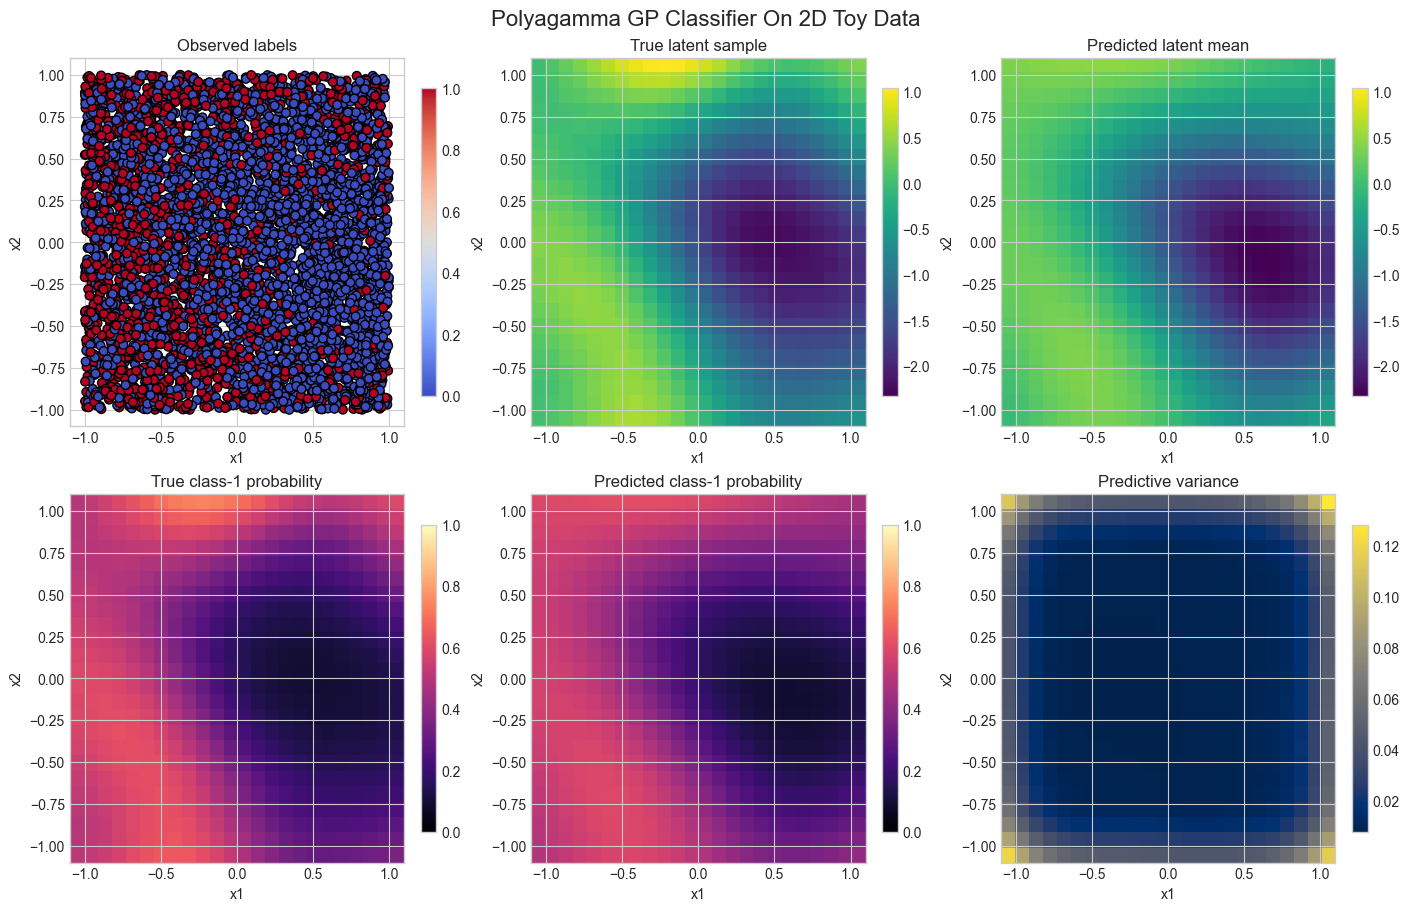

In [5]:
extent = [grid_1d_np.min(), grid_1d_np.max(), grid_1d_np.min(), grid_1d_np.max()]

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

scatter = axes[0, 0].scatter(
    X_train_np[:, 0],
    X_train_np[:, 1],
    c=y_train_np,
    cmap="coolwarm",
    s=40,
    edgecolors="black",
)
axes[0, 0].set_title("Observed labels")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")
fig.colorbar(scatter, ax=axes[0, 0], fraction=0.046)

# Get the min/max values for consistent color scaling
latent_vmin = min(f_grid_true_img.min(), latent_grid_img.min())
latent_vmax = max(f_grid_true_img.max(), latent_grid_img.max())

im = axes[0, 1].imshow(
    f_grid_true_img.T,
    origin="lower",
    extent=extent,
    cmap="viridis",
    vmin=latent_vmin,
    vmax=latent_vmax,
    aspect="auto",
)
# axes[0, 1].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", s=12, edgecolors="black")
axes[0, 1].set_title("True latent sample")
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_ylabel("x2")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046)

im = axes[0, 2].imshow(
    latent_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="viridis",
    vmin=latent_vmin,
    vmax=latent_vmax,
    aspect="auto",
)
# axes[0, 2].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", s=12, edgecolors="black")
axes[0, 2].set_title("Predicted latent mean")
axes[0, 2].set_xlabel("x1")
axes[0, 2].set_ylabel("x2")
fig.colorbar(im, ax=axes[0, 2], fraction=0.046)

im = axes[1, 0].imshow(
    p_grid_true_img.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)
# axes[1, 0].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", s=12, edgecolors="black")
axes[1, 0].set_title("True class-1 probability")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 0], fraction=0.046)

im = axes[1, 1].imshow(
    prob_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)
# axes[1, 1].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", s=12, edgecolors="black")
axes[1, 1].set_title("Predicted class-1 probability")
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046)

im = axes[1, 2].imshow(
    var_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="cividis",
    aspect="auto",
)
# axes[1, 2].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", s=12, edgecolors="black")
axes[1, 2].set_title("Predictive variance")
axes[1, 2].set_xlabel("x1")
axes[1, 2].set_ylabel("x2")
fig.colorbar(im, ax=axes[1, 2], fraction=0.046)

fig.suptitle("Polyagamma GP Classifier On 2D Toy Data", fontsize=16)


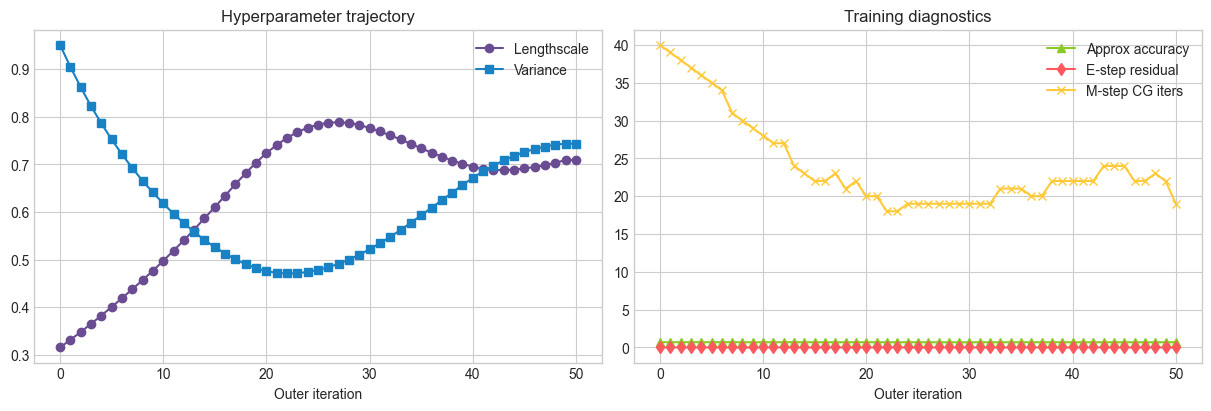

In [6]:
history = clf.history_
iters = np.array([row["iter"] for row in history], dtype=float)
lengthscales = np.array([row["lengthscale"] for row in history], dtype=float)
variances = np.array([row["variance"] for row in history], dtype=float)
accuracies = np.array([row["approx_accuracy"] for row in history], dtype=float)
e_residuals = np.array([row["e_residual"] for row in history], dtype=float)
m_cg_iters = np.array([row["m_cg_iters"] for row in history], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(iters, lengthscales, marker="o", color="#6a4c93", label="Lengthscale")
axes[0].plot(iters, variances, marker="s", color="#1982c4", label="Variance")
axes[0].set_title("Hyperparameter trajectory")
axes[0].set_xlabel("Outer iteration")
axes[0].legend(loc="best")

axes[1].plot(iters, accuracies, marker="^", color="#8ac926", label="Approx accuracy")
axes[1].plot(iters, e_residuals, marker="d", color="#ff595e", label="E-step residual")
axes[1].plot(iters, m_cg_iters, marker="x", color="#ffca3a", label="M-step CG iters")
axes[1].set_title("Training diagnostics")
axes[1].set_xlabel("Outer iteration")
axes[1].legend(loc="best")


In [7]:
print("classes_:", clf.classes_)
print("First five training probabilities:", np.round(prob_train[:5], 3))
print("First five training variances:", np.round(var_train[:5], 3))
print("First five predicted labels:", clf.predict(X_train_np[:5]))


classes_: [0 1]
First five training probabilities: [0.534 0.141 0.301 0.356 0.209]
First five training variances: [-0.024 -0.123 -0.021  0.066  0.149]
First five predicted labels: [1 0 0 0 0]
